In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from collections import Counter
import seaborn as sns
from pathlib import Path
import warnings
import time
warnings.filterwarnings('ignore')


import requests
from io import BytesIO
import hashlib
from concurrent.futures import ThreadPoolExecutor, as_completed
import time

from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision import models
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup

from transformers import AutoTokenizer, AutoModel
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
import re 

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from tqdm.auto import tqdm
import json

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [53]:
# Set random seeds for reproducibility
SEED = 101
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

#dataset folder path 
folder_path = "/kaggle/input/datasets/suvroo/amazon-ml"

IMAGE_COL = 'image_link'
TEXT_COL = 'catalog_content'
ID_COL = 'sample_id'

TEST_SAMPLE_SIZE = 10000  # Use 10K for initial testing

Using device: cpu


In [54]:
train_df = pd.read_csv(os.path.join(folder_path,"train.csv"))
test_df = pd.read_csv(os.path.join(folder_path,"test.csv"))

In [55]:
train_df.shape

(75000, 4)

In [56]:
test_df.shape

(75000, 3)

In [57]:
train_df.head()

,sample_id,catalog_content,image_link,price
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97
3,55858,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.34
4,292686,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...",https://m.media-amazon.com/images/I/41sA037+Qv...,66.49


In [58]:
train_df[TEXT_COL][344]

'Item Name: Dr. Pepper Diet Cherry Soda, 12 oz (24 Pack)\nValue: 288.0\nUnit: Fl Oz\n'

In [59]:
def clean_text(text):
    text = str(text)
    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)
    # Replace multiple spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [60]:
train_df[TEXT_COL] = train_df[TEXT_COL].apply(clean_text)
test_df[TEXT_COL] = test_df[TEXT_COL].apply(clean_text)

In [61]:
train_df[TEXT_COL][1]

'Item Name: Salerno Cookies, The Original Butter Cookies, 8 Ounce (Pack of 4) Bullet Point 1: Original Butter Cookies: Classic butter cookies made with real butter Bullet Point 2: Variety Pack: Includes 4 boxes with 32 cookies total Bullet Point 3: Occasion Perfect: Delicious cookies for birthdays, weddings, anniversaries Bullet Point 4: Shareable Treats: Fun to give and enjoy with friends and family Bullet Point 5: Salerno Brand: Trusted brand of delicious butter cookies since 1925 Value: 32.0 Unit: Ounce'

In [62]:
import re

def extract_features(text):
    # Standard format
    m = re.search(
        r"Item Name:\s*(.*?)(?=Bullet Point|Value:|$)",
        text,
        flags=re.DOTALL
    )

    # Alternate format: Item Name 1, Item Name 2, ...
    names = re.findall(
        r"Item Name\s*\d+:\s*(.*?)(?=Item Name\s*\d+:|Bullet Point|Value:|$)",
        text,
        flags=re.DOTALL
    )

    # Determine final item name
    if m:
        item_name = m.group(1).strip()
    elif names:
        item_name = " ".join(n.strip() for n in names)
    else:
        item_name = None

    # Extract all bullet points
    bullets = re.findall(
        r"Bullet Point(?:\s*\d+)?:\s*(.*?)(?=Bullet Point(?:\s*\d+)?:|Value:|$)",
        text,
        flags=re.DOTALL
    )

    bullet_text = " ".join(b.strip() for b in bullets) if bullets else None

    # Extract value (supports integers, decimals, negative values)
    value = re.search(r"Value:\s*([-+]?\d*\.?\d+|nan)", text, flags=re.IGNORECASE)

    if value:
        val = value.group(1)
        value = None if val.lower() == "nan" else float(val)
    else:
        value = None

    # Extract unit
    unit = re.search(r"Unit:\s*(.*)$", text)

    return {
        "item_name": item_name,
        "bullet_text": bullet_text,
        "value": value,
        "unit": unit.group(1).strip() if unit else None
    }

In [63]:
features_df = train_df[TEXT_COL].apply(extract_features).apply(pd.Series)

In [64]:
features_df.head()

,item_name,bullet_text,value,unit
0,"La Victoria Green Taco Sauce Mild, 12 Ounce (P...",None,72.00,Fl Oz
1,"Salerno Cookies, The Original Butter Cookies, ...",Original Butter Cookies: Classic butter cookie...,32.00,Ounce
2,"Bear Creek Hearty Soup Bowl, Creamy Chicken wi...",Loaded with hearty long grain wild rice and ve...,11.40,Ounce
3,Judee’s Blue Cheese Powder 11.25 oz - Gluten-F...,"Add to your favorite appetizers, dips & spread...",11.25,Ounce
4,"kedem Sherry Cooking Wine, 12.7 Ounce - 12 per...","kedem Sherry Cooking Wine, 12.7 Ounce - 12 per...",12.00,Count


In [65]:
features_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   item_name    75000 non-null  object 
 1   bullet_text  60723 non-null  object 
 2   value        74060 non-null  float64
 3   unit         75000 non-null  object 
dtypes: float64(1), object(3)
memory usage: 2.3+ MB


In [66]:
train_df = pd.concat([train_df, features_df], axis=1)

In [67]:
features_df_test = test_df[TEXT_COL].apply(extract_features).apply(pd.Series)

In [68]:
test_df = pd.concat([test_df, features_df_test], axis=1)

In [69]:
train_df.shape

(75000, 8)

In [70]:
train_df_copy = train_df.copy(deep=True)

In [71]:
train_df_copy.head()

,sample_id,catalog_content,image_link,price,item_name,bullet_text,value,unit
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89,"La Victoria Green Taco Sauce Mild, 12 Ounce (P...",None,72.00,Fl Oz
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12,"Salerno Cookies, The Original Butter Cookies, ...",Original Butter Cookies: Classic butter cookie...,32.00,Ounce
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97,"Bear Creek Hearty Soup Bowl, Creamy Chicken wi...",Loaded with hearty long grain wild rice and ve...,11.40,Ounce
3,55858,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.34,Judee’s Blue Cheese Powder 11.25 oz - Gluten-F...,"Add to your favorite appetizers, dips & spread...",11.25,Ounce
4,292686,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...",https://m.media-amazon.com/images/I/41sA037+Qv...,66.49,"kedem Sherry Cooking Wine, 12.7 Ounce - 12 per...","kedem Sherry Cooking Wine, 12.7 Ounce - 12 per...",12.00,Count


In [72]:
train_df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sample_id        75000 non-null  int64  
 1   catalog_content  75000 non-null  object 
 2   image_link       75000 non-null  object 
 3   price            75000 non-null  float64
 4   item_name        75000 non-null  object 
 5   bullet_text      60723 non-null  object 
 6   value            74060 non-null  float64
 7   unit             75000 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 4.6+ MB


In [73]:
train_df_copy["value"].describe()

count    74060.000000
mean        54.293980
std        461.808901
min          0.000000
25%          6.000000
50%         16.000000
75%         48.000000
max      63882.000000
Name: value, dtype: float64

In [74]:
train_df_copy["value"] = train_df_copy["value"].fillna(train_df_copy["value"].median())

In [75]:
train_df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sample_id        75000 non-null  int64  
 1   catalog_content  75000 non-null  object 
 2   image_link       75000 non-null  object 
 3   price            75000 non-null  float64
 4   item_name        75000 non-null  object 
 5   bullet_text      60723 non-null  object 
 6   value            75000 non-null  float64
 7   unit             75000 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 4.6+ MB


In [76]:
train_df_copy["bullet_text"] = train_df_copy["bullet_text"].fillna("")

In [77]:
train_df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sample_id        75000 non-null  int64  
 1   catalog_content  75000 non-null  object 
 2   image_link       75000 non-null  object 
 3   price            75000 non-null  float64
 4   item_name        75000 non-null  object 
 5   bullet_text      75000 non-null  object 
 6   value            75000 non-null  float64
 7   unit             75000 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 4.6+ MB


In [78]:
train_df_copy["texts"] = (
    train_df_copy['item_name']+" "+train_df_copy['bullet_text']
)

In [79]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

X_text = tfidf.fit_transform(train_df_copy["texts"])

In [80]:
X_text.shape

(75000, 5000)

In [81]:
X_num = train_df_copy[["value"]]

In [82]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

train_df_copy["unit_encoded"] = oe.fit_transform(train_df_copy[["unit"]])
X_cat = train_df_copy[["unit_encoded"]]

In [83]:
from scipy.sparse import hstack

X = hstack([X_text, X_num, X_cat])

y = train_df_copy["price"]

In [84]:
from sklearn.model_selection import train_test_split

X_train_1, X_valid_1, y_train_1, y_valid_1 = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [85]:
from lightgbm import LGBMRegressor

base_model_1 = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05
)

# base_model_1.fit(X_train, y_train)

In [86]:
import os

MODELS_PATH = "/kaggle/input/models/rishi412/saved-models/pytorch/default/1"
os.listdir(MODELS_PATH)

['tfidf_name.pkl', 'tfidf_bullet.pkl', 'lgbm.pkl', 'catboost_v1.cbm']

In [87]:
import joblib
base_model_1 = joblib.load(MODELS_PATH+"/lgbm.pkl")

In [88]:
y_pred_1 = base_model_1.predict(X_valid_1)

In [89]:
from sklearn.metrics import root_mean_squared_error

rmse_1 = root_mean_squared_error(y_valid_1, y_pred_1)

print(rmse_1)

31.868845553081908


In [90]:
train_df_copy["price"].describe()

count    75000.000000
mean        23.647654
std         33.376932
min          0.130000
25%          6.795000
50%         14.000000
75%         28.625000
max       2796.000000
Name: price, dtype: float64

In [91]:
from sklearn.metrics import mean_absolute_error, r2_score

print("RMSE:", root_mean_squared_error(y_valid_1, y_pred_1))
print("MAE :", mean_absolute_error(y_valid_1, y_pred_1))
print("R²  :", r2_score(y_valid_1, y_pred_1))

RMSE: 31.868845553081908
MAE : 12.809958966511662
R²  : 0.32704734390790946


In [92]:
train_df_1 = train_df.copy(deep=True)

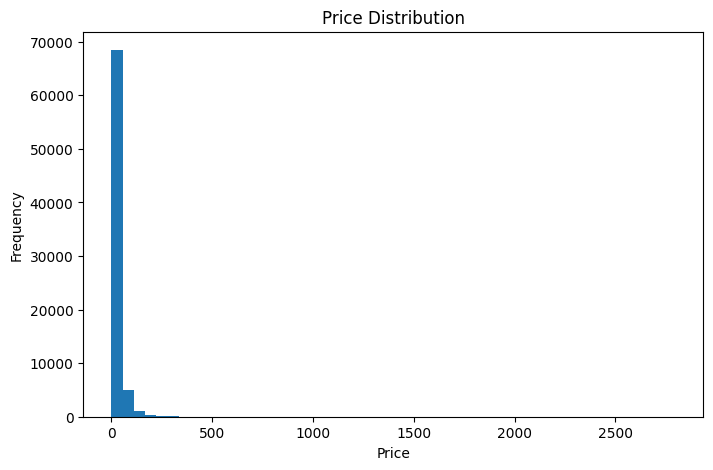

In [93]:
plt.figure(figsize=(8,5))
plt.hist(train_df_1["price"], bins=50)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [94]:
train_df_1["price_log"] = np.log1p(train_df_1["price"])

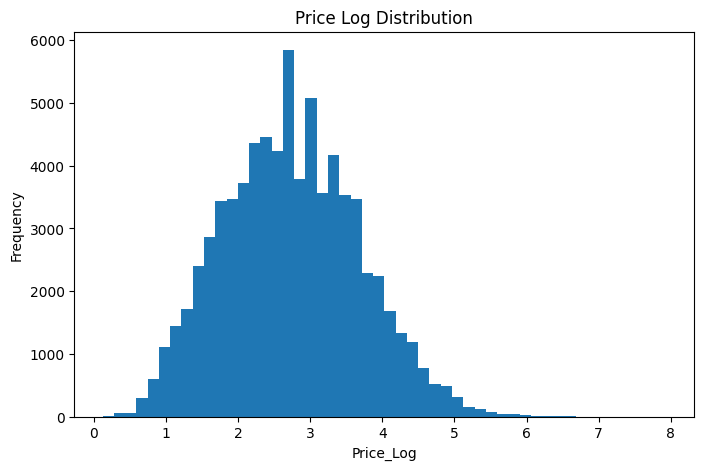

In [95]:
plt.figure(figsize=(8,5))
plt.hist(train_df_1["price_log"], bins=50)
plt.title("Price Log Distribution")
plt.xlabel("Price_Log")
plt.ylabel("Frequency")
plt.show()

In [96]:
train_df_1["brand"] = train_df_1["item_name"].str.split().str[0]

In [97]:
# tfidf_name = TfidfVectorizer(
#     max_features=5000,
#     ngram_range=(1,2),
#     stop_words="english",
#     min_df=2,
#     max_df=0.95
# )
tfidf_name = joblib.load(MODELS_PATH + "/tfidf_name.pkl")
tfidf_bullet = joblib.load(MODELS_PATH + "/tfidf_bullet.pkl")

In [98]:
X_name = tfidf_name.fit_transform(train_df_1["item_name"])

In [99]:
# tfidf_bullet = TfidfVectorizer(
#     max_features=3000,
#     ngram_range=(1,2),
#     stop_words="english",
#     min_df=2,
#     max_df=0.95
# )

X_bullet = tfidf_bullet.fit_transform(train_df_1["bullet_text"].fillna(""))

In [100]:
oe = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

train_df_1["brand_encoded"] = oe.fit_transform(train_df_1[["brand"]])

In [101]:
train_df_1["value"] = train_df_1["value"].fillna(train_df_1["value"].median())

In [102]:
oe_unit = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

In [103]:
train_df_1["unit_encoded"] = oe_unit.fit_transform(train_df_1[["unit"]])

In [104]:
X = hstack([
    X_name,
    X_bullet,
    train_df_1[[
        "value",
        "unit_encoded",
        "brand_encoded"
    ]]
])

In [105]:
y = np.log1p(train_df_1["price"])

In [106]:
from sklearn.model_selection import train_test_split

X_train_2, X_valid_2, y_train_2, y_valid_2 = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [107]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor()

In [108]:
# base_model_2.fit(X_train,y_train)

In [109]:
base_model_2 = cat_model.load_model(MODELS_PATH + "/catboost_v1.cbm")

In [110]:
y_pred_2 = base_model_2.predict(X_valid_2)

In [111]:
rmse_2 = root_mean_squared_error(y_valid_2, y_pred_2)

print(rmse_2)

0.695345342988011


In [112]:
test_df.head()

,sample_id,catalog_content,image_link,item_name,bullet_text,value,unit
0,100179,Item Name: Rani 14-Spice Eshamaya's Mango Chut...,https://m.media-amazon.com/images/I/71hoAn78AW...,Rani 14-Spice Eshamaya's Mango Chutney (Indian...,You'll LOVE our 14-Spice Eshamaya's Mango Chut...,10.5,Ounce
1,245611,Item Name: Natural MILK TEA Flavoring extract ...,https://m.media-amazon.com/images/I/61ex8NHCIj...,Natural MILK TEA Flavoring extract by HALO PAN...,"Authentic Tasting, Asian-Inspired Natural flav...",2.0,Fl Oz
2,146263,Item Name: Honey Filled Hard Candy - Bulk Pack...,https://m.media-amazon.com/images/I/61KCM61J8e...,Honey Filled Hard Candy - Bulk Pack 2 Pounds -...,Honey Filled Hard Candy; 2-pound bulk pack; ap...,32.0,Ounce
3,95658,Item Name: Vlasic Snack'mm's Kosher Dill 16 Oz...,https://m.media-amazon.com/images/I/51Ex6uOH7y...,Vlasic Snack'mm's Kosher Dill 16 Oz (Pack of 2),None,2.0,Count
4,36806,"Item Name: McCormick Culinary Vanilla Extract,...",https://m.media-amazon.com/images/I/71QYlrOMoS...,"McCormick Culinary Vanilla Extract, 32 fl oz -...",PREMIUM INGREDIENTS: McCormick Culinary Pure V...,32.0,Fl Oz


In [113]:
X_name_test = tfidf_name.transform(test_df["item_name"])

In [114]:
X_bullet_test = tfidf_bullet.transform(test_df["bullet_text"].fillna(""))

In [115]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sample_id        75000 non-null  int64  
 1   catalog_content  75000 non-null  object 
 2   image_link       75000 non-null  object 
 3   item_name        75000 non-null  object 
 4   bullet_text      60725 non-null  object 
 5   value            73989 non-null  float64
 6   unit             75000 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 4.0+ MB


In [116]:
test_df["value"] = test_df["value"].fillna(test_df["value"].median())

In [117]:
test_df["bullet_text"] = test_df["bullet_text"].fillna("")

In [118]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sample_id        75000 non-null  int64  
 1   catalog_content  75000 non-null  object 
 2   image_link       75000 non-null  object 
 3   item_name        75000 non-null  object 
 4   bullet_text      75000 non-null  object 
 5   value            75000 non-null  float64
 6   unit             75000 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 4.0+ MB


In [119]:
test_df["brand"] = test_df["item_name"].str.split().str[0]

In [120]:
test_df["unit_encoded"] = oe_unit.transform(test_df[["unit"]])

In [121]:
test_df["brand_encoded"] = oe.transform(test_df[["brand"]])

In [122]:
X_test = hstack([
    X_name_test,
    X_bullet_test,
    test_df[[
        "value",
        "unit_encoded",
        "brand_encoded"
    ]]
])

In [123]:
pred_log = base_model_2.predict(X_test)
predictions = np.expm1(pred_log)

In [124]:
submission = pd.DataFrame({
    "sample_id": test_df["sample_id"],
    "price": predictions
})

submission.to_csv("submission.csv", index=False)

In [125]:
submission.head()

,sample_id,price
0,100179,14.475281
1,245611,14.801395
2,146263,25.380617
3,95658,12.725093
4,36806,30.249165


In [126]:
PATH = "/kaggle/input/datasets/rishi412/actual"

In [127]:
actual_path = PATH + '/submission.txt'

In [128]:
actual = pd.read_csv(actual_path)
actual.head()

,sample_id,price
0,100179,14.016
1,245611,12.410
2,146263,14.734
3,95658,5.383
4,36806,29.450


In [129]:
import numpy as np

def smape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    diff = np.abs(y_true - y_pred)

    # Avoid division by zero
    mask = denominator != 0

    return np.mean(diff[mask] / denominator[mask]) * 100

In [130]:
from sklearn.metrics import (
    root_mean_squared_error,
    mean_absolute_error,
    r2_score
)

merged = actual.merge(submission, on="sample_id", suffixes=("_actual", "_pred"))

print("Rows matched:", len(merged))

rmse = root_mean_squared_error(
    merged["price_actual"],
    merged["price_pred"]
)

mae = mean_absolute_error(
    merged["price_actual"],
    merged["price_pred"]
)

r2 = r2_score(
    merged["price_actual"],
    merged["price_pred"]
)

print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

Rows matched: 75000
RMSE : 10.4912
MAE  : 6.2452
R²   : 0.3617


In [131]:
score = smape(
    merged["price_actual"],
    merged["price_pred"]
)

print(f"SMAPE: {score:.4f}%")

SMAPE: 33.1709%


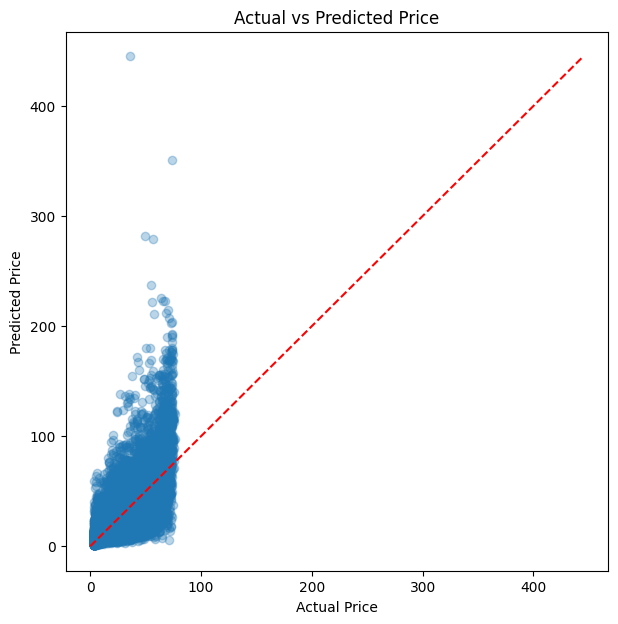

In [132]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))
plt.scatter(
    merged["price_actual"],
    merged["price_pred"],
    alpha=0.3
)

# Perfect prediction line
mx = max(merged["price_actual"].max(), merged["price_pred"].max())
plt.plot([0, mx], [0, mx], 'r--')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

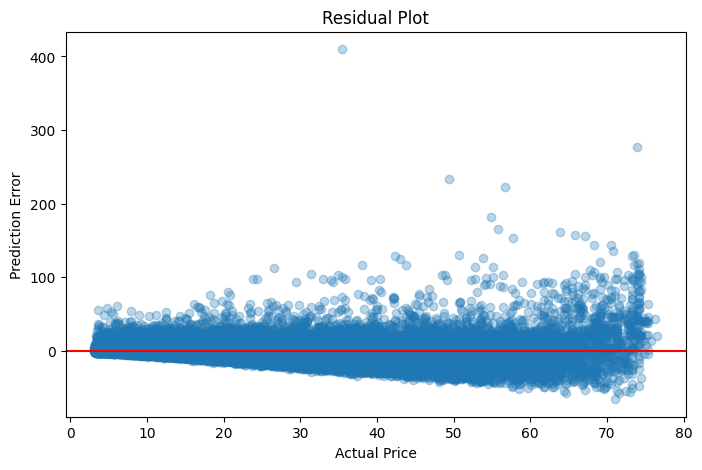

In [133]:
merged["error"] = merged["price_pred"] - merged["price_actual"]

plt.figure(figsize=(8,5))
plt.scatter(
    merged["price_actual"],
    merged["error"],
    alpha=0.3
)

plt.axhline(0, color="red")
plt.xlabel("Actual Price")
plt.ylabel("Prediction Error")
plt.title("Residual Plot")
plt.show()

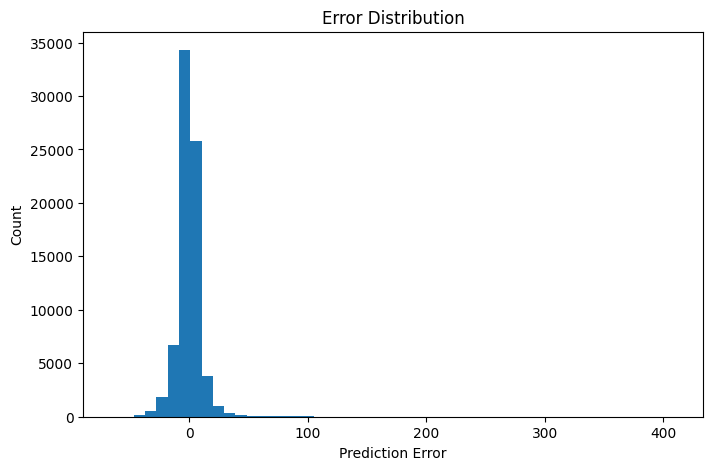

In [134]:
plt.figure(figsize=(8,5))
plt.hist(merged["error"], bins=50)
plt.xlabel("Prediction Error")
plt.ylabel("Count")
plt.title("Error Distribution")
plt.show()

In [135]:
IMAGES_PATH = Path('./downloaded_images')
IMAGES_PATH.mkdir(exist_ok=True)
IMAGES_PATH_train = Path("/kaggle/input/datasets/suvroo/amazon-ml/train/images")
IMAGES_PATH_test = Path("/kaggle/input/datasets/suvroo/amazon-ml/test/images")
SAVE_PATH = Path('./models')
SAVE_PATH.mkdir(exist_ok=True)

In [136]:
train_df_2 = train_df.copy(deep=True)

In [137]:
train_df_2.head()

,sample_id,catalog_content,image_link,price,item_name,bullet_text,value,unit
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89,"La Victoria Green Taco Sauce Mild, 12 Ounce (P...",None,72.00,Fl Oz
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12,"Salerno Cookies, The Original Butter Cookies, ...",Original Butter Cookies: Classic butter cookie...,32.00,Ounce
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97,"Bear Creek Hearty Soup Bowl, Creamy Chicken wi...",Loaded with hearty long grain wild rice and ve...,11.40,Ounce
3,55858,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.34,Judee’s Blue Cheese Powder 11.25 oz - Gluten-F...,"Add to your favorite appetizers, dips & spread...",11.25,Ounce
4,292686,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...",https://m.media-amazon.com/images/I/41sA037+Qv...,66.49,"kedem Sherry Cooking Wine, 12.7 Ounce - 12 per...","kedem Sherry Cooking Wine, 12.7 Ounce - 12 per...",12.00,Count


In [138]:
IMAGE_DIR = Path("/kaggle/input/datasets/suvroo/amazon-ml/train/images")

train_df_2["image_path"] = train_df_2["image_link"].apply(
    lambda x: IMAGE_DIR / Path(x).name
)


In [139]:
train_df_2.head()

,sample_id,catalog_content,image_link,price,item_name,bullet_text,value,unit,image_path
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89,"La Victoria Green Taco Sauce Mild, 12 Ounce (P...",None,72.00,Fl Oz,/kaggle/input/datasets/suvroo/amazon-ml/train/...
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12,"Salerno Cookies, The Original Butter Cookies, ...",Original Butter Cookies: Classic butter cookie...,32.00,Ounce,/kaggle/input/datasets/suvroo/amazon-ml/train/...
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97,"Bear Creek Hearty Soup Bowl, Creamy Chicken wi...",Loaded with hearty long grain wild rice and ve...,11.40,Ounce,/kaggle/input/datasets/suvroo/amazon-ml/train/...
3,55858,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.34,Judee’s Blue Cheese Powder 11.25 oz - Gluten-F...,"Add to your favorite appetizers, dips & spread...",11.25,Ounce,/kaggle/input/datasets/suvroo/amazon-ml/train/...
4,292686,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...",https://m.media-amazon.com/images/I/41sA037+Qv...,66.49,"kedem Sherry Cooking Wine, 12.7 Ounce - 12 per...","kedem Sherry Cooking Wine, 12.7 Ounce - 12 per...",12.00,Count,/kaggle/input/datasets/suvroo/amazon-ml/train/...


In [140]:
train_df_2["image_path"][0]

PosixPath('/kaggle/input/datasets/suvroo/amazon-ml/train/images/51mo8htwTHL.jpg')

In [141]:
device

device(type='cpu')

In [142]:
import torch
from torchvision import models

eff_model = models.efficientnet_b0(weights="DEFAULT")

# Remove classification head
feature_extractor = torch.nn.Sequential(*list(eff_model.children())[:-1]).to(device)
feature_extractor.eval()

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 184MB/s]


Sequential(
  (0): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivation(
    

In [143]:
train_df_2.head()

,sample_id,catalog_content,image_link,price,item_name,bullet_text,value,unit,image_path
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89,"La Victoria Green Taco Sauce Mild, 12 Ounce (P...",None,72.00,Fl Oz,/kaggle/input/datasets/suvroo/amazon-ml/train/...
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12,"Salerno Cookies, The Original Butter Cookies, ...",Original Butter Cookies: Classic butter cookie...,32.00,Ounce,/kaggle/input/datasets/suvroo/amazon-ml/train/...
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97,"Bear Creek Hearty Soup Bowl, Creamy Chicken wi...",Loaded with hearty long grain wild rice and ve...,11.40,Ounce,/kaggle/input/datasets/suvroo/amazon-ml/train/...
3,55858,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.34,Judee’s Blue Cheese Powder 11.25 oz - Gluten-F...,"Add to your favorite appetizers, dips & spread...",11.25,Ounce,/kaggle/input/datasets/suvroo/amazon-ml/train/...
4,292686,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...",https://m.media-amazon.com/images/I/41sA037+Qv...,66.49,"kedem Sherry Cooking Wine, 12.7 Ounce - 12 per...","kedem Sherry Cooking Wine, 12.7 Ounce - 12 per...",12.00,Count,/kaggle/input/datasets/suvroo/amazon-ml/train/...


In [144]:
train_df_2 = train_df_2.drop(columns=[
        "item_name",
        "bullet_text",
        "value", "unit"
    ])

In [145]:
train_df_2.head()

,sample_id,catalog_content,image_link,price,image_path
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89,/kaggle/input/datasets/suvroo/amazon-ml/train/...
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12,/kaggle/input/datasets/suvroo/amazon-ml/train/...
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97,/kaggle/input/datasets/suvroo/amazon-ml/train/...
3,55858,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.34,/kaggle/input/datasets/suvroo/amazon-ml/train/...
4,292686,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...",https://m.media-amazon.com/images/I/41sA037+Qv...,66.49,/kaggle/input/datasets/suvroo/amazon-ml/train/...


In [146]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
import nltk


STOP_WORDS = set(stopwords.words('english'))
PUNCT = string.punctuation

def clean_text(text):
    """Lowercase, remove punctuation and stopwords."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)  
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in STOP_WORDS and not word.isnumeric()]
    return " ".join(tokens)

def parse_catalog_content(text):

    if pd.isna(text):
        return {
            "item_name": None,
            "brand_name": None,
            "bullet_points": None,
            "product_description": None,
            "value": None,
            "unit": None,
        }

    result = {}

    item = re.search(
        r"Item Name:\s*(.*?)(?=Bullet Point\s*\d*:|Product Description:|Value:|Unit:|$)",
        text,
        flags=re.DOTALL,
    )

    bullets = re.findall(
        r"Bullet Point\s*\d*:\s*(.*?)(?=Bullet Point\s*\d*:|Product Description:|Value:|Unit:|$)",
        text,
        flags=re.DOTALL,
    )

    desc = re.search(
        r"Product Description:\s*(.*?)(?=Value:|Unit:|$)",
        text,
        flags=re.DOTALL,
    )

    value = re.search(
        r"Value:\s*([\d.]+)",
        text
    )

    unit = re.search(
        r"Unit:\s*(.*)$",
        text
    )

    result["item_name"] = clean_text(item.group(1)) if item else None

    if item:
        item_text = item.group(1).strip()
    
        result["item_name"] = clean_text(item_text)
    
        words = item_text.split()
        result["brand_name"] = words[0] if words else None
    else:
        result["item_name"] = None
        result["brand_name"] = None
    
    result["bullet_points"] = (
        " ".join(clean_text(x) for x in bullets)
        if bullets else None
    )

    result["product_description"] = (
        clean_text(desc.group(1))
        if desc else None
    )

    result["value"] = (
        float(value.group(1))
        if value else None
    )

    result["unit"] = (
        unit.group(1).strip().lower()
        if unit else None
    )

    return result

In [147]:
text = train_df_2.loc[4,"catalog_content"]
text

'Item Name: kedem Sherry Cooking Wine, 12.7 Ounce - 12 per case. Bullet Point: kedem Sherry Cooking Wine, 12.7 Ounce - 12 per case. Value: 12.0 Unit: Count'

In [148]:
parse_catalog_content(text)

{'item_name': 'kedem sherry cooking wine ounce per case',
 'brand_name': 'kedem',
 'bullet_points': 'kedem sherry cooking wine ounce per case',
 'product_description': None,
 'value': 12.0,
 'unit': 'count'}

In [149]:
parsed = train_df_2["catalog_content"].apply(parse_catalog_content)

In [150]:
parsed_df = pd.json_normalize(parsed)

In [151]:
train_df_2 = pd.concat([train_df_2, parsed_df], axis=1)

In [152]:
train_df_2.head()

,sample_id,catalog_content,image_link,price,image_path,item_name,brand_name,bullet_points,product_description,value,unit
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89,/kaggle/input/datasets/suvroo/amazon-ml/train/...,la victoria green taco sauce mild ounce pack,La,None,None,72.00,fl oz
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12,/kaggle/input/datasets/suvroo/amazon-ml/train/...,salerno cookies original butter cookies ounce ...,Salerno,original butter cookies classic butter cookies...,None,32.00,ounce
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97,/kaggle/input/datasets/suvroo/amazon-ml/train/...,bear creek hearty soup bowl creamy chicken ric...,Bear,loaded hearty long grain wild rice vegetables ...,None,11.40,ounce
3,55858,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.34,/kaggle/input/datasets/suvroo/amazon-ml/train/...,judees blue cheese powder oz glutenfree nutfre...,Judee’s,add favorite appetizers dips spreads use seaso...,judees powdered blue cheese cheddar cheese pow...,11.25,ounce
4,292686,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...",https://m.media-amazon.com/images/I/41sA037+Qv...,66.49,/kaggle/input/datasets/suvroo/amazon-ml/train/...,kedem sherry cooking wine ounce per case,kedem,kedem sherry cooking wine ounce per case,None,12.00,count


In [153]:
train_df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   sample_id            75000 non-null  int64  
 1   catalog_content      75000 non-null  object 
 2   image_link           75000 non-null  object 
 3   price                75000 non-null  float64
 4   image_path           75000 non-null  object 
 5   item_name            74993 non-null  object 
 6   brand_name           74992 non-null  object 
 7   bullet_points        60723 non-null  object 
 8   product_description  32533 non-null  object 
 9   value                74060 non-null  float64
 10  unit                 75000 non-null  object 
dtypes: float64(2), int64(1), object(8)
memory usage: 6.3+ MB


In [154]:
train_df_2["item_name"] = train_df_2["item_name"].fillna("")

train_df_2["brand_name"] = train_df_2["brand_name"].fillna("Unknown")

train_df_2["bullet_points"] = train_df_2["bullet_points"].fillna("")

train_df_2["product_description"] = train_df_2["product_description"].fillna("")

train_df_2["value"] = train_df_2["value"].fillna(

    train_df_2["value"].median()

)

In [155]:
train_df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   sample_id            75000 non-null  int64  
 1   catalog_content      75000 non-null  object 
 2   image_link           75000 non-null  object 
 3   price                75000 non-null  float64
 4   image_path           75000 non-null  object 
 5   item_name            75000 non-null  object 
 6   brand_name           75000 non-null  object 
 7   bullet_points        75000 non-null  object 
 8   product_description  75000 non-null  object 
 9   value                75000 non-null  float64
 10  unit                 75000 non-null  object 
dtypes: float64(2), int64(1), object(8)
memory usage: 6.3+ MB


In [156]:
from torchvision import transforms
from PIL import Image

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [157]:
# from tqdm.auto import tqdm

# embeddings = []

# with torch.no_grad():
#     for path in tqdm(
#     train_df_2["image_path"],
#     total=len(train_df_2),
#     desc="Images",
#     unit="img"
# ):
#         if not os.path.exists(path):
#             embeddings.append(np.zeros(1280, dtype=np.float32))
#             continue

#         img = Image.open(path).convert("RGB")
#         img = transform(img).unsqueeze(0).to(device)

#         feat = feature_extractor(img)
#         feat = feat.squeeze().cpu().numpy()

#         embeddings.append(feat)

In [158]:
# image_features = np.array(embeddings, dtype=np.float32)
image_features = np.load("/kaggle/input/models/rishi412/embeddings/pytorch/default/1/image_embeddings.npy")
print(image_features.shape)

(75000, 1280)


In [159]:
train_df_2.head(1)

,sample_id,catalog_content,image_link,price,image_path,item_name,brand_name,bullet_points,product_description,value,unit
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89,/kaggle/input/datasets/suvroo/amazon-ml/train/...,la victoria green taco sauce mild ounce pack,La,,,72.0,fl oz


In [160]:
name_vectorizer = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1,2),
    stop_words="english"
)

bullet_vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2),
    stop_words="english"
)

desc_vectorizer = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1,2),
    stop_words="english"
)

X_name = name_vectorizer.fit_transform(train_df_2["item_name"])

X_bullet = bullet_vectorizer.fit_transform(
    train_df_2["bullet_points"]
)

X_desc = desc_vectorizer.fit_transform(
    train_df_2["product_description"]
)

In [161]:
joblib.dump(
    name_vectorizer,
    "/kaggle/working/models/name_vectorizer.pkl"
)

joblib.dump(
    bullet_vectorizer,
    "/kaggle/working/models/bullet_vectorizer.pkl"
)

joblib.dump(
    desc_vectorizer,
    "/kaggle/working/models/desc_vectorizer.pkl"
)

['/kaggle/working/models/desc_vectorizer.pkl']

In [162]:
oe_unit = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)
oe = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

In [163]:
train_df_2["brand_encoded"] = oe.fit_transform(train_df_2[["brand_name"]])
train_df_2["unit_encoded"] = oe_unit.fit_transform(train_df_2[["unit"]])

In [165]:
joblib.dump(
    oe,
    "/kaggle/working/models/brand_encoder.pkl"
)
joblib.dump(
    oe_unit,
    "/kaggle/working/models/unit_encoder.pkl"
)

['/kaggle/working/models/unit_encoder.pkl']

In [166]:
from scipy.sparse import hstack
from scipy.sparse import csr_matrix

X = hstack([
    X_name,
    X_bullet,
    X_desc,
    csr_matrix(image_features),
    train_df_2[[
        "value",
        "unit_encoded",
        "brand_encoded"
    ]]
])

In [167]:
y = np.log1p(train_df_2["price"])

In [168]:
print(X.shape)
print(y.shape)

(75000, 66283)
(75000,)


In [169]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [170]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=3000,
    learning_rate=0.03,
    num_leaves=127,
    max_depth=-1,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    random_state=42,
    n_jobs=-1
)

# lgb_model.fit(
#     X_train,
#     y_train,
#     eval_set=[(X_valid_3, y_valid_3)],
#     eval_metric="l2",
#     callbacks=[
#         lgb.early_stopping(100),
#         lgb.log_evaluation(100)
#     ]
# )

In [171]:
lgb_model = joblib.load("/kaggle/input/models/rishi412/lgb-model/pytorch/default/1/lgb_model.pkl")

In [172]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
pred_log = lgb_model.predict(X_valid)

pred_price = np.expm1(pred_log)
true_price = np.expm1(y_valid)

mae = mean_absolute_error(true_price, pred_price)
rmse = np.sqrt(mean_squared_error(true_price, pred_price))
r2 = r2_score(true_price, pred_price)
print(f"mae: {mae} \nrmse: {rmse} \nr2: {r2}")

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
mae: 11.420706681558842 
rmse: 33.042570126122115 
r2: 0.27656504469042575


In [173]:
def smape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    diff = np.abs(y_true - y_pred)

    # Avoid division by zero
    mask = denominator != 0

    return np.mean(diff[mask] / denominator[mask]) * 100

In [174]:
smape(true_price, pred_price)

np.float64(51.26706645135306)

In [175]:
print("RMSE:", root_mean_squared_error(y_valid_1, y_pred_1))
print("MAE :", mean_absolute_error(y_valid_1, y_pred_1))
print("R²  :", r2_score(y_valid_1, y_pred_1))

RMSE: 31.868845553081908
MAE : 12.809958966511662
R²  : 0.32704734390790946


In [176]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    iterations=3000,
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=5,
    random_seed=42,
    early_stopping_rounds=200,
    verbose=100
)

# cat_model.fit(
#     X_train,
#     y_train,
#     eval_set=(X_valid, y_valid),
#     use_best_model=True
# )

0:	learn: 0.9339476	test: 0.9467969	best: 0.9467969 (0)	total: 10.3s	remaining: 8h 33m 14s
100:	learn: 0.7706351	test: 0.7975673	best: 0.7975673 (100)	total: 10m 14s	remaining: 4h 54m 2s
200:	learn: 0.7406091	test: 0.7719121	best: 0.7719121 (200)	total: 20m	remaining: 4h 38m 33s
300:	learn: 0.7243988	test: 0.7588962	best: 0.7588962 (300)	total: 29m 44s	remaining: 4h 26m 37s
400:	learn: 0.7110959	test: 0.7487503	best: 0.7487503 (400)	total: 39m 28s	remaining: 4h 15m 51s
500:	learn: 0.6984079	test: 0.7408532	best: 0.7408532 (500)	total: 49m 14s	remaining: 4h 5m 39s
600:	learn: 0.6878699	test: 0.7349714	best: 0.7349714 (600)	total: 59m 1s	remaining: 3h 55m 37s
700:	learn: 0.6790380	test: 0.7303884	best: 0.7303884 (700)	total: 1h 8m 47s	remaining: 3h 45m 36s
800:	learn: 0.6707172	test: 0.7265587	best: 0.7265587 (800)	total: 1h 18m 34s	remaining: 3h 35m 41s
900:	learn: 0.6631349	test: 0.7231801	best: 0.7231801 (900)	total: 1h 28m 18s	remaining: 3h 25m 42s
1000:	learn: 0.6566129	test: 0.7206

CatBoostRegressor(depth=8, early_stopping_rounds=200, eval_metric='RMSE', iterations=3000, l2_leaf_reg=5, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=100)

In [ ]:
cat_model = cat_model.load_model("/kaggle/working/catboost.cbm")

In [179]:
pred_log = cat_model.predict(X_valid)

pred_price = np.expm1(pred_log)
true_price = np.expm1(y_valid)

mae = mean_absolute_error(true_price, pred_price)
rmse = np.sqrt(mean_squared_error(true_price, pred_price))
r2 = r2_score(true_price, pred_price)
print(f"mae: {mae} \nrmse: {rmse} \nr2: {r2}")

mae: 12.082944680309435 
rmse: 33.6281070712666 
r2: 0.25069834519765144


In [180]:
smape(true_price, pred_price)

np.float64(54.000627325665626)

In [181]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Predictions on validation set (log scale)
lgb_pred = lgb_model.predict(X_valid)
cat_pred = cat_model.predict(X_valid)

# Ensemble on log scale
ensemble_pred = 0.5 * lgb_pred + 0.5 * cat_pred

# Convert back to original price
ensemble_price = np.expm1(ensemble_pred)
true_price = np.expm1(y_valid)

mae = mean_absolute_error(true_price, ensemble_price)

print("Ensemble MAE:", mae)

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
Ensemble MAE: 11.627080733484458


In [182]:
mae = mean_absolute_error(true_price, ensemble_price)
rmse = np.sqrt(mean_squared_error(true_price, ensemble_price))
r2 = r2_score(true_price, ensemble_price)
print(f"mae: {mae} \nrmse: {rmse} \nr2: {r2}")

mae: 11.627080733484458 
rmse: 33.23207047960884 
r2: 0.26824339835922273
